# Assignment 1 — Uncertainty and Sentiment Analysis of Quarterly and Annual Financial Reports

**FRE-GY 7871 A · NLP and the Investment Process · Param Shah (pks9550)**

The corpus is every 10-K and 10-Q filed 2021–2025 by the SEC-registered filers in the six ARK
ETFs. Each filing is scored on the Loughran–McDonald **Fin-Neg** and **Fin-Unc** word lists, two
ways — a simple proportional share and the tf.idf weighting of equation (1) — and the scores are
then put against realised volatility and filing-period excess returns.

Notebook order follows the exhibits. Each section says which of the six questions it answers.
Everything the assignment asks the student to write lives in `src/analysis.py`, `src/sample.py`,
`src/measures.py` and `src/exhibits.py`; the instructor's pipeline modules are unchanged.

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

from src.analysis import selfcheck_tfidf
from src.sample import build_sample, MIN_WORDS, MIN_PRICE, MIN_TRADING_DAYS
from src.measures import build_panel
from src.lexicons import load_all
from src import exhibits as ex

OUT = "outputs/"

def save(df, name):
    """Write a table to outputs/ so the report can cite it, and return it."""
    df.to_csv(f"{OUT}{name}.csv", index=False)
    return df

pct = "{:.3%}".format

## 1. Method validation — the tf.idf self-check

Before the weighting touches a real filing it has to reproduce the worked example in the brief.
Equation (1), with natural logs throughout:

$$\mathrm{tfidf}(w, j) \;=\; \frac{1 + \ln\,\mathrm{tf}(w, j)}{1 + \ln a_j}\;\times\;\ln\frac{N}{\mathrm{df}(w)}$$

`tf` is the raw count of the word in the document and words with `tf = 0` are skipped, so `ln 0`
never arises. **`a_j` is the average word count *within document j*** — total words over distinct
words — which is a per-document quantity, not a corpus-wide one. `N` is the number of documents in
the corpus being scored and `df(w)` the number of those documents containing `w` at least once.
Only words on the lexicon are ever scored; general vocabulary enters solely through `a_j` and the
total-word denominator.

Expected: **0.8480, 0.2885, 0.5026**. Getting 0.368 for d1 would mean log base 10.

In [2]:
chk = selfcheck_tfidf()
expected = {"d1": (0.7500, 0.8480), "d2": (0.3333, 0.2885), "d3": (0.7500, 0.5026)}

display(chk[["words", "n_words", "n_distinct", "a_j", "proportional", "tfidf"]].round(6))
print("word list = {LOSS, RISK};  GAIN is a distractor and is never scored")
print("doc_freq =", chk.attrs["doc_freq"], " N =", chk.attrs["N"])
print()
ok = True
for d, (ep, et) in expected.items():
    p, t = chk.loc[d, "proportional"], chk.loc[d, "tfidf"]
    good = abs(p - ep) < 5e-5 and abs(t - et) < 5e-5
    ok &= good
    print(f"{d}: proportional {p:.4f} (want {ep:.4f}) | tf.idf {t:.4f} (want {et:.4f})  "
          f"{'PASS' if good else 'FAIL'}")
print()
print("SELF-CHECK", "PASSED" if ok else "FAILED")
assert ok, "tf.idf does not reproduce the brief's worked example"

,words,n_words,n_distinct,a_j,proportional,tfidf
doc,,,,,,
d1,LOSS LOSS RISK GAIN,4,3,1.333333,0.750000,0.848018
d2,LOSS GAIN GAIN,3,2,1.500000,0.333333,0.288492
d3,RISK RISK RISK GAIN,4,2,2.000000,0.750000,0.502564


word list = {LOSS, RISK};  GAIN is a distractor and is never scored
doc_freq = {'LOSS': 2, 'RISK': 2}  N = 3

d1: proportional 0.7500 (want 0.7500) | tf.idf 0.8480 (want 0.8480)  PASS
d2: proportional 0.3333 (want 0.3333) | tf.idf 0.2885 (want 0.2885)  PASS
d3: proportional 0.7500 (want 0.7500) | tf.idf 0.5026 (want 0.5026)  PASS

SELF-CHECK PASSED


## 2. Word lists

Sizes, and the overlap between the two lists. The overlap matters because it puts a floor under
how independent the two measures can possibly be (§3 of the report).

In [3]:
L = load_all()
neg, unc = L["Negative"], L["Uncertainty"]
overlap = neg & unc

print(f"Fin-Neg (Negative)     {len(neg):5d} words")
print(f"Fin-Unc (Uncertainty)  {len(unc):5d} words")
print(f"On both lists          {len(overlap):5d} words "
      f"({len(overlap)/len(unc):.1%} of Fin-Unc, {len(overlap)/len(neg):.1%} of Fin-Neg)")
print()
print("The shared words:")
print(", ".join(sorted(overlap)))
print()
# The tokeniser emits hyphenated and apostrophe forms; the lists contain none.
print("hyphenated words on either list:",
      len([w for w in neg | unc if "-" in w]))
print("apostrophe words on either list:",
      len([w for w in neg | unc if "'" in w]))

Fin-Neg (Negative)      2355 words
Fin-Unc (Uncertainty)    297 words
On both lists             40 words (13.5% of Fin-Unc, 1.7% of Fin-Neg)

The shared words:
ANOMALIES, ANOMALOUS, ANOMALOUSLY, ANOMALY, CONFUSES, CONFUSING, CONFUSINGLY, CONFUSION, DESTABILIZING, DEVIATE, DEVIATED, DEVIATES, DEVIATING, DEVIATION, DEVIATIONS, DOUBT, DOUBTED, DOUBTFUL, DOUBTS, INCOMPLETENESS, INSTABILITY, REASSESSMENT, REASSESSMENTS, RISKIER, RISKIEST, RISKY, SUSCEPTIBILITY, TURBULENCE, UNDETERMINED, UNDOCUMENTED, UNEXPECTED, UNEXPECTEDLY, UNFORSEEN, UNPLANNED, UNPREDICTABILITY, UNPREDICTABLE, UNPREDICTABLY, UNPREDICTED, VOLATILE, VOLATILITY

hyphenated words on either list: 0
apostrophe words on either list: 0


## 3. Sample construction — **Table 1**

The waterfall runs from the frozen ARK holdings snapshot to the estimation sample in one table,
with a `remaining` column at every step. Filters are applied in the order the brief fixes.

Two recorded steps are **not** in the brief's numbered list and are labelled as such, because a
filter that was applied and not reported is worse than one that was never applied:

* **Amendments** — script `02` calls `list_filings(include_amendments=False)`, so 10-K/A and 10-Q/A
  were excluded before anything was downloaded. Re-listing with amendments included counts them.
* **Duplicate accessions** — script `02` iterates over *tickers*, and Alphabet is held by ARK as
  both GOOG and GOOGL under a single CIK, so its filings arrived twice. Same document, not two
  filings. Class A (GOOGL) is kept.

In [4]:
built = build_sample()
sample, table1 = built["sample"], built["table1"]
calendar, panel_px = built["calendar"], built["panel"]

print(f"thresholds: 10-K >= {MIN_WORDS['10-K']:,} words, 10-Q >= {MIN_WORDS['10-Q']:,}; "
      f"price >= ${MIN_PRICE:.2f}; >= {MIN_TRADING_DAYS} trading days either side of day 0")
print()
display(save(table1, "table1_waterfall"))

print(f"Final sample: {len(sample):,} filings, {sample['cik'].nunique()} firms, "
      f"{sample['cal_quarter'].nunique()} quarters "
      f"({sample['cal_quarter'].min()} to {sample['cal_quarter'].max()})")
print(sample["form"].value_counts().to_string())

thresholds: 10-K >= 2,000 words, 10-Q >= 1,000; price >= $3.00; >= 60 trading days either side of day 0



,step,removed,remaining,note
0,"ARK holdings positions (6 funds, frozen snapshot)",NaN,226,union of the six funds' published holdings
1,Unique US-listed tickers after cleaning,102.0,124,"drops cross-fund duplicates, crypto and non-US..."
2,Drop: no CIK on file (foreign or private filer),7.0,117,"ADYEN, ARKY, BYDDY, HO, KMTUY, PRNT, SE"
3,"Drop: CIK found, no 10-K or 10-Q in 2021-2025",24.0,93,"foreign private issuers filing 20-F/40-F, and ..."
4,"Candidate 10-K / 10-Q filings, 2021-2025",NaN,1748,"includes amendments, before any filing-level f..."
5,"1. Drop amendments (10-K/A, 10-Q/A) and parse ...",46.0,1702,46 amendments excluded at the EDGAR query stag...
6,"1b. Drop duplicate accessions (same CIK, two s...",20.0,1682,not in the brief's list. Alphabet is held as G...
7,2. Drop filings under the word-count floor,0.0,1682,"2,000 words for a 10-K, 1,000 for a 10-Q"
8,3. Keep one filing per company per calendar qu...,14.0,1668,earliest filing date kept; ties broken by acce...
9,4. Require a usable day 0 and a day -1 price o...,103.0,1565,28 lacked a tradable day 0 or a day -1 close; ...


Final sample: 1,542 filings, 91 firms, 20 quarters (2021Q1 to 2025Q4)
form
10-Q    1158
10-K     384


### Trading calendar

Built from the trading days actually present in the downloaded SPY series, not from an external
market-calendar package, so holidays and early closes are whatever the price history says.

In [5]:
print(f"{len(calendar):,} trading days, {calendar[0].date()} to {calendar[-1].date()}")
print(f"2021-2025 only: {((calendar >= '2021-01-01') & (calendar <= '2025-12-31')).sum():,} days")

1,400 trading days, 2020-09-01 to 2026-03-30
2021-2025 only: 1,255 days


## 4. The day-0 rule

Day 0 is the first trading day on or after the **later** of the EDGAR filing date and the
acceptance date, where `acceptance_datetime` is converted from UTC to America/New_York first and
pushed forward one calendar day when it lands at or after 16:00 Eastern.

The brief asks how many filings this moves relative to naively trading the filing date.

In [6]:
n = len(sample)
moved = int(sample["day0_moved"].sum())
after = int(sample["acc_after_close"].sum())

print(f"accepted at or after 16:00 Eastern : {after:5d} of {n:,} ({after/n:.1%})")
print(f"day 0 MOVED vs the naive rule      : {moved:5d} of {n:,} ({moved/n:.1%})")
print()
shift = (sample["day0"] - sample["day0_naive"]).dt.days
print("shift in calendar days:")
display(shift.value_counts().sort_index().rename("filings").to_frame().T)

hours = sample["acceptance_datetime"].dt.tz_convert("America/New_York").dt.hour
print("acceptance hour, America/New_York (note the spike at 16:00):")
display(hours.value_counts().sort_index().rename("filings").to_frame().T)

accepted at or after 16:00 Eastern :  1155 of 1,542 (74.9%)
day 0 MOVED vs the naive rule      :   862 of 1,542 (55.9%)

shift in calendar days:


,0,1,2,3,4
filings,680,700,1,141,20


acceptance hour, America/New_York (note the spike at 16:00):


acceptance_datetime,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21
filings,31,109,78,47,22,22,12,15,15,36,721,179,83,54,54,64


## 5. Scoring the corpus

Both lexicons, both weightings. `df` and `N` are computed on the **final estimation sample** — the
same 1,542 documents the regressions run on. Scoring one corpus and regressing another is
explicitly penalised, and deriving both from `sample` here is what stops them drifting apart.

In [7]:
panel, wordfreq, diag = build_panel(sample, panel_px, built["inputs"]["shares"], use_cache=True)
prices = built["inputs"]["prices"]
panel["year"] = pd.PeriodIndex(panel["cal_quarter"], freq="Q").year.astype(str)

print(f"panel: {panel.shape[0]:,} filings x {panel.shape[1]} columns")
print()
print("coverage of the outcomes and controls:")
for c in ["exret_0_3", "pre_exret", "pre_vol", "post_vol", "log_size", "log_dollar_vol"]:
    miss = panel[c].isna().sum()
    print(f"  {c:16s} {panel[c].notna().sum():5,} present, {miss:3d} missing")
print()
print("share counts come from the filing being scored, never a current count:")
print(panel["shares_tag"].value_counts(dropna=False).to_string())

panel: 1,542 filings x 43 columns

coverage of the outcomes and controls:
  exret_0_3        1,542 present,   0 missing
  pre_exret        1,542 present,   0 missing
  pre_vol          1,542 present,   0 missing
  post_vol         1,542 present,   0 missing
  log_size         1,497 present,  45 missing
  log_dollar_vol   1,542 present,   0 missing

share counts come from the filing being scored, never a current count:
shares_tag
dei:EntityCommonStockSharesOutstanding                     1014
us-gaap:WeightedAverageNumberOfDilutedSharesOutstanding     459
NaN                                                          45
us-gaap:CommonStockSharesOutstanding                         21
us-gaap:WeightedAverageNumberOfSharesOutstandingBasic         3


## 6. **Table 2** — summary statistics, and the correlation between the measures

Answers **Q2** (are sentiment and uncertainty measuring different things) and supplies the
variance comparison **Q5** asks for between form types.

In [8]:
t2 = ex.table2(panel)
display(save(t2, "table2_summary_stats").round(5))

,form,measure,n,mean,sd,min,p25,median,p75,max,cv
0,10-K,"Negative, proportional",384,0.02547,0.00451,0.01277,0.02260,0.02576,0.02868,0.03626,0.17699
1,10-K,"Negative, tf.idf",384,167.19400,61.29330,59.55415,119.80417,152.97564,205.36915,345.88518,0.36660
2,10-K,"Uncertainty, proportional",384,0.02113,0.00263,0.01415,0.01941,0.02136,0.02297,0.02795,0.12434
3,10-K,"Uncertainty, tf.idf",384,27.55420,9.71432,10.29964,20.29506,26.03488,32.41340,64.12629,0.35255
4,10-Q,"Negative, proportional",1158,0.02172,0.01078,0.00365,0.01222,0.01773,0.03316,0.05044,0.49616
5,10-Q,"Negative, tf.idf",1158,75.85661,72.89599,2.14105,16.30235,34.42379,133.98416,284.36230,0.96097
6,10-Q,"Uncertainty, proportional",1158,0.01933,0.00661,0.00630,0.01389,0.01762,0.02609,0.03580,0.34200
7,10-Q,"Uncertainty, tf.idf",1158,12.69751,8.66859,1.34069,5.58501,9.89874,19.16607,40.77110,0.68270
8,All,"Negative, proportional",1542,0.02266,0.00974,0.00365,0.01326,0.02298,0.03178,0.05044,0.42998
9,All,"Negative, tf.idf",1542,98.60211,80.52689,2.14105,19.40346,96.18940,157.78921,345.88518,0.81669


In [9]:
corr = ex.measure_correlations(panel)
display(save(corr, "table2b_correlations").round(4))

,weighting,form,n,pearson,spearman
0,Proportional,All,1542,0.8875,0.8937
1,Proportional,10-K,384,0.7677,0.7473
2,Proportional,10-Q,1158,0.8921,0.8441
3,tf.idf,All,1542,0.9344,0.9365
4,tf.idf,10-K,384,0.8563,0.8431
5,tf.idf,10-Q,1158,0.9435,0.9135
6,Negative: prop vs tf.idf,All,1542,0.7942,0.8297
7,Uncertainty: prop vs tf.idf,All,1542,0.6295,0.7177


## 7. **Table 3** — the thirty most frequent words on each list

Answers **Q1**: what is each measure actually made of, and for Uncertainty in particular, is the
count driven by management hedging or by the standing furniture of a risk-factor section.

In [10]:
t3 = ex.table3(wordfreq, top=30)
save(t3, "table3_top_words")
for lex in ["Negative", "Uncertainty"]:
    print(f"--- {lex} ---")
    sub = t3[t3["lexicon"] == lex]
    display(sub[["rank", "word", "count", "share_of_lexicon_count", "cumulative_share"]]
            .style.format({"share_of_lexicon_count": "{:.3%}",
                           "cumulative_share": "{:.1%}", "count": "{:,}"})
            .hide(axis="index"))

--- Negative ---


rank,word,count,share_of_lexicon_count,cumulative_share
1,LOSS,"57,793",4.751%,4.8%
2,ADVERSELY,"57,066",4.691%,9.4%
3,ADVERSE,"35,207",2.894%,12.3%
4,CLAIMS,"32,908",2.705%,15.0%
5,HARM,"26,192",2.153%,17.2%
6,AGAINST,"26,019",2.139%,19.3%
7,UNABLE,"25,990",2.137%,21.5%
8,FAILURE,"24,699",2.031%,23.5%
9,LOSSES,"23,712",1.949%,25.5%
10,LITIGATION,"22,980",1.889%,27.3%


--- Uncertainty ---


rank,word,count,share_of_lexicon_count,cumulative_share
1,MAY,"373,348",37.373%,37.4%
2,COULD,"206,338",20.655%,58.0%
3,RISK,"50,347",5.040%,63.1%
4,RISKS,"49,849",4.990%,68.1%
5,BELIEVE,"31,369",3.140%,71.2%
6,APPROXIMATELY,"18,161",1.818%,73.0%
7,ASSUMPTIONS,"13,140",1.315%,74.3%
8,FLUCTUATIONS,"12,656",1.267%,75.6%
9,MIGHT,"12,473",1.249%,76.8%
10,UNCERTAINTIES,"12,313",1.233%,78.1%


In [11]:
conc = ex.concentration(wordfreq)
display(save(conc, "table3b_concentration").round(4))

,lexicon,distinct_words_used,total_occurrences,top10_share,top30_share,top50_share
0,Negative,1565,1216382,0.2734,0.4608,0.5653
1,Uncertainty,243,998968,0.7808,0.9244,0.9611


### Why the two weightings of the *same* list disagree

The idf term is `ln(N / df)`. A word appearing in **every** filing has `df = N`, so its idf is
exactly **zero** and it contributes nothing to tf.idf no matter how often it occurs. This is not a
rounding issue — it is an identity. The check below is the single most important diagnostic in the
notebook for reading Tables 4–6.

In [12]:
from src.analysis import doc_frequency
from src.measures import load_corpus_counts

counts, _ = load_corpus_counts(sample)
N = len(sample)
rows = []
for lex in ["Negative", "Uncertainty"]:
    dfc, _ = doc_frequency(counts, L[lex])
    top = wordfreq[wordfreq["lexicon"] == lex].nlargest(8, "count")
    for _, x in top.iterrows():
        d = dfc.get(x["word"], 0)
        rows.append({"lexicon": lex, "word": x["word"], "count": x["count"],
                     "share_of_list": x["share_of_lexicon_count"],
                     "df": d, "df_pct_of_N": d / N,
                     "idf = ln(N/df)": np.log(N / d) if d else np.nan})
idf_tbl = pd.DataFrame(rows)
display(save(idf_tbl, "table3c_idf_weights")
        .style.format({"share_of_list": "{:.2%}", "df_pct_of_N": "{:.1%}",
                       "idf = ln(N/df)": "{:.4f}", "count": "{:,}"}).hide(axis="index"))
print(f"N = {N:,} documents")

  tokenised 250/1542


  tokenised 500/1542


  tokenised 750/1542


  tokenised 1000/1542


  tokenised 1250/1542


  tokenised 1500/1542


lexicon,word,count,share_of_list,df,df_pct_of_N,idf = ln(N/df)
Negative,LOSS,"57,793",4.75%,1542,100.0%,0.0000
Negative,ADVERSELY,"57,066",4.69%,1439,93.3%,0.0691
Negative,ADVERSE,"35,207",2.89%,1411,91.5%,0.0888
Negative,CLAIMS,"32,908",2.71%,1286,83.4%,0.1815
Negative,HARM,"26,192",2.15%,1079,70.0%,0.3570
Negative,AGAINST,"26,019",2.14%,1338,86.8%,0.1419
Negative,UNABLE,"25,990",2.14%,1233,80.0%,0.2236
Negative,FAILURE,"24,699",2.03%,1195,77.5%,0.2549
Uncertainty,MAY,"373,348",37.37%,1542,100.0%,0.0000
Uncertainty,COULD,"206,338",20.66%,1542,100.0%,0.0000


N = 1,542 documents


## 8. **Q2 continued** — a filing that scores high on one measure and low on the other

Scores are standardised within form type, so a 10-K is compared with other 10-Ks.

In [13]:
div = ex.divergent_filings(panel, n=4)
display(save(div, "q2_divergent_filings")
        .style.format({"prop_negative": "{:.3%}", "prop_uncertainty": "{:.3%}",
                       "z_prop_negative": "{:+.2f}", "z_prop_uncertainty": "{:+.2f}",
                       "gap": "{:+.2f}", "n_words_scored": "{:,}"}).hide(axis="index"))

ticker,company,form,filing_date,n_words_scored,prop_negative,prop_uncertainty,z_prop_negative,z_prop_uncertainty,gap,direction
DKNG,DraftKings Inc.,10-Q,2024-11-08 00:00:00,"14,156",5.044%,1.639%,+2.66,-0.44,+3.11,"high negative, low uncertainty"
DKNG,DraftKings Inc.,10-Q,2024-08-02 00:00:00,"13,877",4.720%,1.729%,+2.36,-0.31,+2.67,"high negative, low uncertainty"
DKNG,DraftKings Inc.,10-Q,2024-05-03 00:00:00,"12,094",4.854%,1.844%,+2.49,-0.13,+2.62,"high negative, low uncertainty"
DKNG,DraftKings Inc.,10-Q,2023-05-05 00:00:00,"10,834",4.726%,1.846%,+2.37,-0.13,+2.50,"high negative, low uncertainty"
ILMN,"ILLUMINA, INC.",10-K,2022-02-18 00:00:00,"30,070",2.039%,2.384%,-1.13,+1.03,-2.16,"low negative, high uncertainty"
ILMN,"ILLUMINA, INC.",10-K,2021-02-17 00:00:00,"29,760",2.130%,2.416%,-0.92,+1.15,-2.08,"low negative, high uncertainty"
OKLO,Oklo Inc.,10-K,2025-03-24 00:00:00,"35,959",2.931%,2.795%,+0.85,+2.59,-1.74,"low negative, high uncertainty"
ILMN,"ILLUMINA, INC.",10-K,2023-02-17 00:00:00,"31,589",2.320%,2.403%,-0.50,+1.10,-1.60,"low negative, high uncertainty"


In [14]:
from collections import Counter
from src.sample import read_counts

for tick, date in [("DKNG", "2024-11-08"), ("ILMN", "2022-02-18")]:
    row = panel[(panel["ticker"] == tick) & (panel["filing_date"] == date)].iloc[0]
    c, nw, nd = read_counts(row["text_path"])
    print(f"{tick} {row['form']} {date} — {nw:,} words | "
          f"negative {row['prop_negative']:.2%}, uncertainty {row['prop_uncertainty']:.2%}")
    for lex in ["Negative", "Uncertainty"]:
        top = Counter({w: c[w] for w in L[lex] if c.get(w, 0) > 0}).most_common(8)
        print(f"   {lex:12s} " + ", ".join(f"{w}:{n}" for w, n in top))
    print()

DKNG 10-Q 2024-11-08 — 14,156 words | negative 5.04%, uncertainty 1.64%
   Negative     LOSS:76, DAMAGES:57, COMPLAINT:42, ADVERSE:40, PLAINTIFF:37, DISMISS:36, CLAIMS:29, AGAINST:24
   Uncertainty  MAY:48, COULD:42, BELIEVE:19, POSSIBLE:17, PENDING:16, DEPENDING:14, PREDICT:14, RISK:11

ILMN 10-K 2022-02-18 — 30,070 words | negative 2.04%, uncertainty 2.38%
   Negative     ADVERSELY:41, LOSS:36, ADVERSE:24, CRITICAL:17, IMPAIRMENT:16, AGAINST:15, NEGATIVELY:13, CLAIMS:12
   Uncertainty  MAY:193, COULD:125, RISK:41, RISKS:36, CONTINGENT:34, INTANGIBLE:28, ASSUMPTIONS:26, BELIEVE:19



## 9. **Figure 1** — the two measures over 2021–2025, with VIX

**The composition corrections come before any description of the chart.** Two of them:

1. **Form mix.** 10-Ks are longer and much heavier in risk language than 10-Qs, and they cluster in
   the first calendar quarter — 2021Q1 carries 57 10-Ks against 8 10-Qs. Pooling the forms
   therefore manufactures a calendar sawtooth that is an artefact of the filing calendar. The forms
   are drawn separately.
2. **Observation count per point.** Even after separating, a *quarterly* 10-K mean outside Q1 is
   the average of one or two filings and swings wildly for no substantive reason. The 10-K series
   is therefore annual (~77 filings a point); the 10-Q series stays quarterly (60–80 a point).
3. **Firm mix.** Firms differ in baseline tone, so a changing set of filers moves a pooled mean on
   its own. The within-firm specification in Table 4 is what handles this.

Figure 1b shows the composition being corrected for, rather than merely asserting it.

In [15]:
series = ex.quarterly_series(panel, prices)
print("filings per quarter by form:")
display(series["n_by_form_q"].T)
print("filings per year by form:")
display(series["n_by_form_year"].T)

filings per quarter by form:


q,2021Q1,2021Q2,2021Q3,2021Q4,2022Q1,2022Q2,2022Q3,2022Q4,2023Q1,2023Q2,2023Q3,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3,2025Q4
form,,,,,,,,,,,,,,,,,,,,
10-K,57,1,2,6,68,4,2,6,67,2,2,6,68,2,2,6,72,2,2,7
10-Q,8,67,72,71,8,76,80,72,9,72,76,68,9,74,75,74,10,77,81,79


filings per year by form:


year,2021,2022,2023,2024,2025
form,,,,,
10-K,66,80,77,78,83
10-Q,218,236,225,232,247


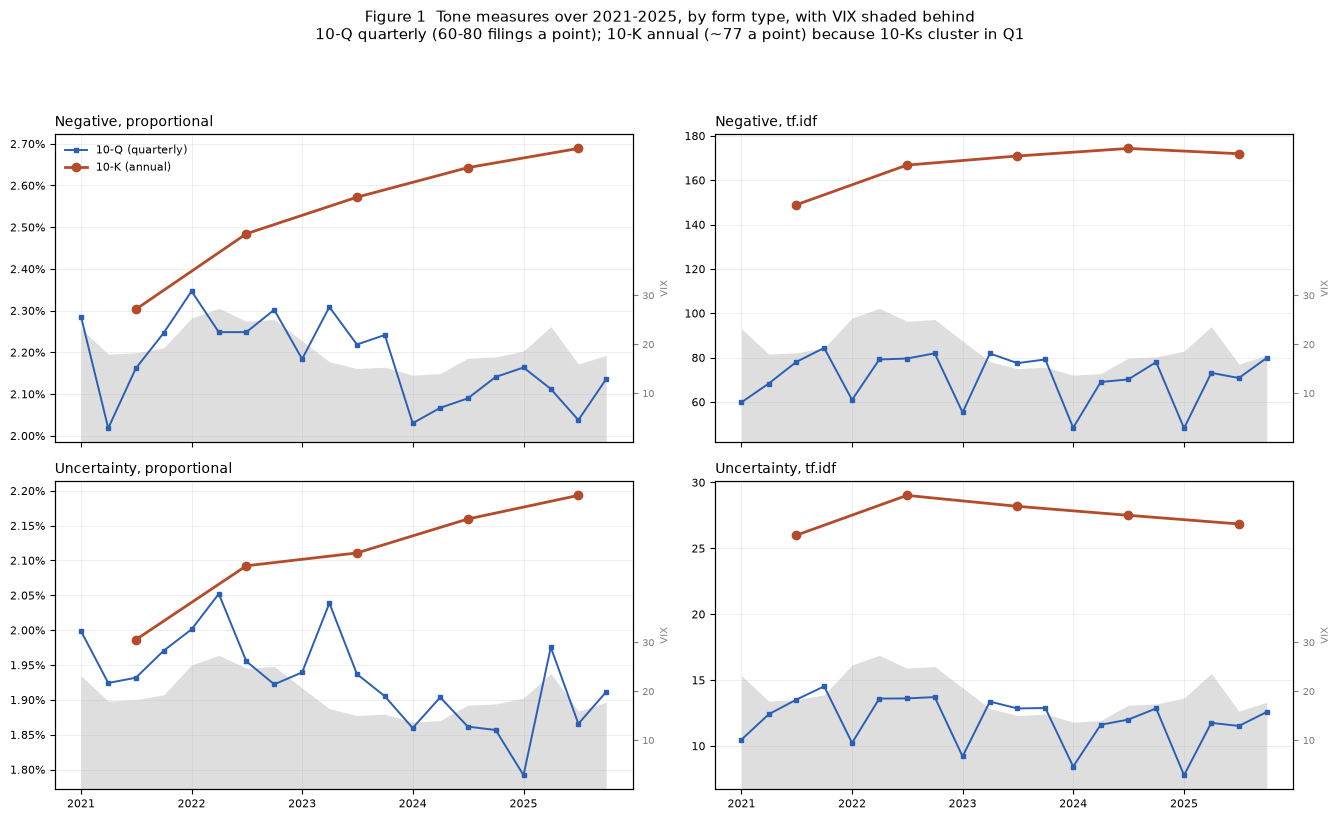

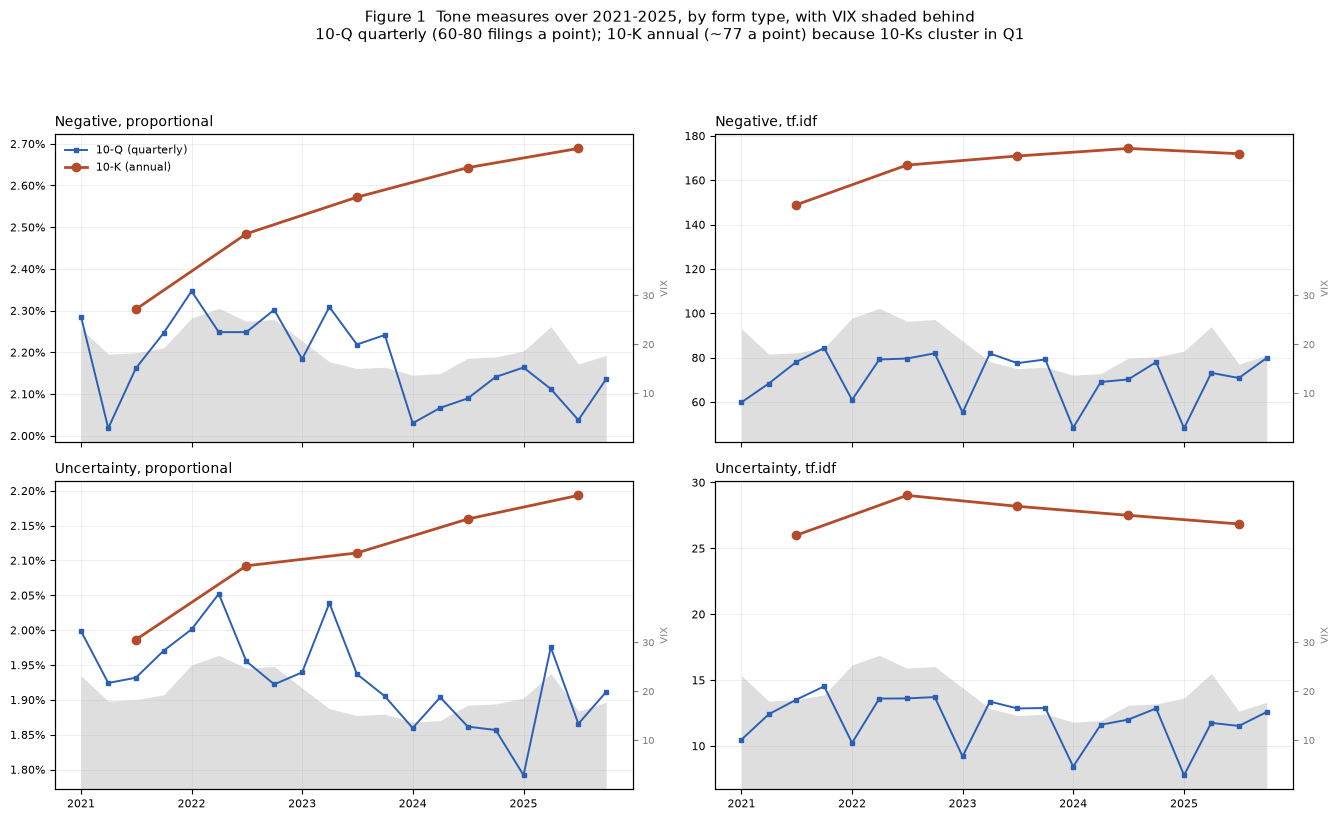

In [16]:
fig = ex.plot_figure1(series, OUT + "figure1_tone_by_quarter.png")
fig

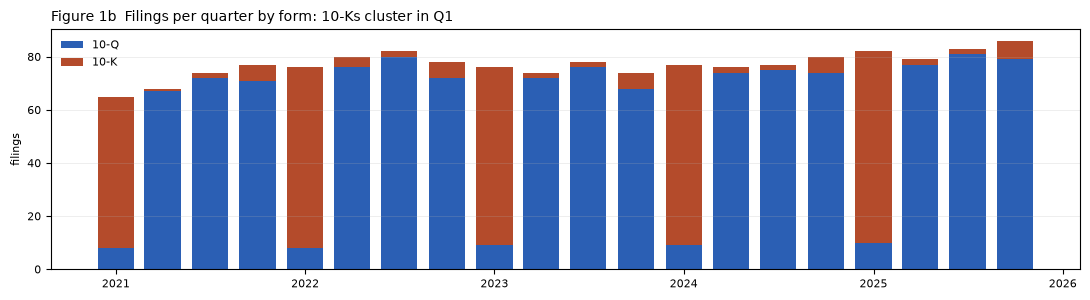

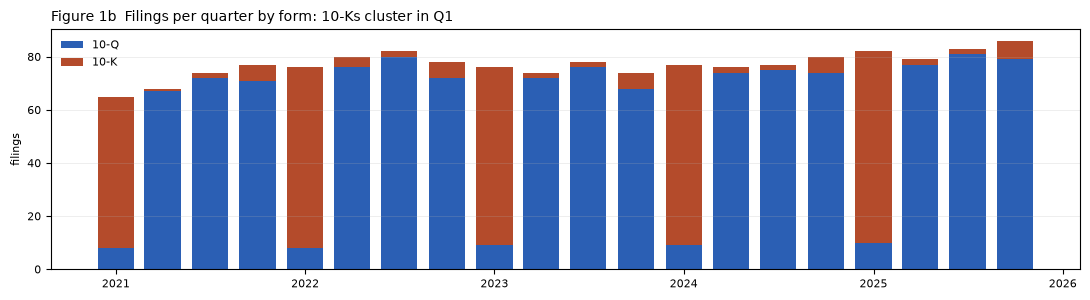

In [17]:
fig = ex.plot_composition(series, OUT + "figure1b_composition.png")
fig

## 10. **Table 4** — trend tests

Answers **Q3**. Two specifications per measure:

* **Aggregate** — the quarterly mean regressed on a linear time trend, reported with both OLS and
  Newey–West t-statistics. Newey–West is required rather than optional here: twenty quarterly
  observations of a persistent series regressed on time will produce a confident-looking OLS
  t-statistic whether or not a trend exists, because the residuals are autocorrelated.
* **Within-firm** — the filing-level measure on a time trend in years with firm fixed effects,
  standard errors clustered by firm. This asks whether *the same company* changed its language,
  which is the question the trend is supposed to be about. **This is the specification to lead
  with.**

In [18]:
t4_all = ex.table4(panel, series)
display(save(t4_all, "table4_trends_all").round(5))

,measure,form,agg_n_quarters,agg_slope_per_year,agg_t_ols,agg_t_nw,agg_nw_lags,within_n,within_slope_per_year,within_t,within_p
0,"Negative, proportional",All,20,-0.00011,-0.36648,-0.42092,2,1542,-0.00010,-0.65435,0.51289
1,"Negative, tf.idf",All,20,-3.12566,-0.54423,-0.86668,2,1542,-0.67426,-0.71805,0.47272
2,"Uncertainty, proportional",All,20,-0.00009,-0.66138,-0.87533,2,1542,-0.00011,-1.29972,0.19370
3,"Uncertainty, tf.idf",All,20,-0.90643,-0.98370,-1.55957,2,1542,-0.53459,-4.46081,0.00001


### Table 4 by form type — part of **Q5**

The pooled result and the split results tell different stories, which is the point of running it.

In [19]:
t4_form = pd.concat([ex.table4(panel, series, form=f) for f in ["10-K", "10-Q"]],
                    ignore_index=True)
display(save(t4_form, "table4_trends_by_form").round(5))

,measure,form,agg_n_quarters,agg_slope_per_year,agg_t_ols,agg_t_nw,agg_nw_lags,within_n,within_slope_per_year,within_t,within_p
0,"Negative, proportional",10-K,20,0.00058,2.13916,3.84241,2,384,0.00081,8.26807,0.00000
1,"Negative, tf.idf",10-K,20,1.13115,0.27434,0.39428,2,384,3.71132,4.05581,0.00005
2,"Uncertainty, proportional",10-K,20,0.00029,1.95863,2.72410,2,384,0.00037,5.80977,0.00000
3,"Uncertainty, tf.idf",10-K,20,-0.87234,-1.20591,-1.86546,2,384,-0.34668,-2.37978,0.01732
4,"Negative, proportional",10-Q,20,-0.00032,-2.27327,-2.15760,2,1158,-0.00036,-1.88491,0.05944
5,"Negative, tf.idf",10-Q,20,-0.57307,-0.32321,-0.42731,2,1158,-1.90377,-1.62667,0.10381
6,"Uncertainty, proportional",10-Q,20,-0.00026,-3.01565,-3.23991,2,1158,-0.00026,-2.39809,0.01648
7,"Uncertainty, tf.idf",10-Q,20,-0.31496,-1.10047,-1.50468,2,1158,-0.57002,-4.07058,0.00005


## 11. **Table 5** — does uncertainty language predict realised volatility?

Answers **Q4**. The dependent variable is annualised realised volatility over [+4, +63]; the
uncertainty measure is standardised so the coefficient reads per one standard deviation.

Four specifications, in two pairs. The brief asks for the comparison with and without the
pre-filing volatility control, and **the gap between the two is the answer, not either number on
its own**. The pooled fixed-effects pair is reported alongside because firm fixed effects absorb
the same between-firm channel that `pre_vol` is there to absorb — so the interesting contrast
only appears in the pair that leaves the cross-section in.

In [20]:
t5_all = ex.table5(panel)
display(save(t5_all, "table5_volatility_all").round(4))

,measure,form,spec,n,coef_per_sd,se,t,p,pre_vol_coef,pre_vol_t,r2
0,"Uncertainty, proportional",All,"(1) no FE, without pre-filing vol",1497,0.0493,0.0123,3.9925,0.0001,NaN,NaN,0.3469
1,"Uncertainty, proportional",All,"(2) no FE, with pre-filing vol",1497,0.0388,0.0106,3.6556,0.0003,0.1071,2.3825,0.4637
2,"Uncertainty, proportional",All,"(3) firm+quarter FE, without pre-filing vol",1497,-0.0088,0.0070,-1.2593,0.2079,NaN,NaN,0.7310
3,"Uncertainty, proportional",All,"(4) firm+quarter FE, with pre-filing vol",1497,-0.0091,0.0068,-1.3393,0.1805,0.0294,2.2391,0.7360
4,"Uncertainty, tf.idf",All,"(1) no FE, without pre-filing vol",1497,0.0684,0.0160,4.2819,0.0000,NaN,NaN,0.3569
5,"Uncertainty, tf.idf",All,"(2) no FE, with pre-filing vol",1497,0.0532,0.0140,3.7930,0.0001,0.1053,2.3515,0.4691
6,"Uncertainty, tf.idf",All,"(3) firm+quarter FE, without pre-filing vol",1497,0.0002,0.0097,0.0204,0.9837,NaN,NaN,0.7307
7,"Uncertainty, tf.idf",All,"(4) firm+quarter FE, with pre-filing vol",1497,-0.0004,0.0092,-0.0397,0.9683,0.0294,2.2490,0.7357


### Table 5 by form type — the rest of **Q5**

Year fixed effects replace quarter fixed effects on the splits: firms file one 10-K a year, so on
the 10-K subsample firm and quarter dummies are nearly collinear and the design matrix comes back
rank-deficient, which makes the standard errors meaningless.

In [21]:
t5_form = pd.concat([ex.table5(panel, form=f, time_fe="year") for f in ["10-K", "10-Q"]],
                    ignore_index=True)
display(save(t5_form, "table5_volatility_by_form").round(4))

,measure,form,spec,n,coef_per_sd,se,t,p,pre_vol_coef,pre_vol_t,r2
0,"Uncertainty, proportional",10-K,"(1) no FE, without pre-filing vol",369,0.0687,0.0142,4.8467,0.0000,NaN,NaN,0.3281
1,"Uncertainty, proportional",10-K,"(2) no FE, with pre-filing vol",369,0.0613,0.0191,3.2126,0.0013,0.1270,2.2353,0.4906
2,"Uncertainty, proportional",10-K,"(3) firm+year FE, without pre-filing vol",369,-0.0106,0.0248,-0.4293,0.6677,NaN,NaN,0.7978
3,"Uncertainty, proportional",10-K,"(4) firm+year FE, with pre-filing vol",369,0.0033,0.0248,0.1318,0.8952,0.0785,4.8130,0.8302
4,"Uncertainty, tf.idf",10-K,"(1) no FE, without pre-filing vol",369,0.0878,0.0146,6.0295,0.0000,NaN,NaN,0.3599
5,"Uncertainty, tf.idf",10-K,"(2) no FE, with pre-filing vol",369,0.0733,0.0175,4.1931,0.0000,0.1212,2.1125,0.5060
6,"Uncertainty, tf.idf",10-K,"(3) firm+year FE, without pre-filing vol",369,0.0048,0.0378,0.1273,0.8987,NaN,NaN,0.7977
7,"Uncertainty, tf.idf",10-K,"(4) firm+year FE, with pre-filing vol",369,0.0254,0.0371,0.6841,0.4939,0.0792,4.6595,0.8306
8,"Uncertainty, proportional",10-Q,"(1) no FE, without pre-filing vol",1128,0.0515,0.0133,3.8606,0.0001,NaN,NaN,0.3686
9,"Uncertainty, proportional",10-Q,"(2) no FE, with pre-filing vol",1128,0.0400,0.0105,3.7969,0.0001,0.0992,2.5866,0.4685


## 12. **Table 6** — does tone predict the filing-period excess return?

The dependent variable is the [0, +3] excess return against SPY, measured from the close on day
−1. **The power arithmetic is stated before the coefficients are interpreted.** The brief is
explicit that this test is underpowered, so a null here is the correct and expected answer, not a
failure to find something.

In [22]:
t6 = ex.table6(panel)
display(save(t6, "table6_returns").round(5))

,measure,spec,n,coef_per_sd,se,t,p,r2
0,"Negative, proportional",(1) measure only,1497,-0.00471,0.00299,-1.57733,0.11472,0.00166
1,"Negative, proportional",(2) + controls,1497,-0.00510,0.00284,-1.79615,0.07247,0.01048
2,"Negative, proportional",(3) + controls + FE,1497,-0.01163,0.00591,-1.96964,0.04888,0.10163
3,"Negative, tf.idf",(1) measure only,1497,-0.00546,0.00299,-1.82843,0.06748,0.00223
4,"Negative, tf.idf",(2) + controls,1497,-0.00707,0.00351,-2.01348,0.04406,0.01139
5,"Negative, tf.idf",(3) + controls + FE,1497,-0.01165,0.00801,-1.45444,0.14582,0.10105
6,"Uncertainty, proportional",(1) measure only,1497,-0.00603,0.00298,-2.02443,0.04293,0.00273
7,"Uncertainty, proportional",(2) + controls,1497,-0.00650,0.00276,-2.35441,0.01855,0.01162
8,"Uncertainty, proportional",(3) + controls + FE,1497,-0.01120,0.00667,-1.67809,0.09333,0.10150
9,"Uncertainty, tf.idf",(1) measure only,1497,-0.00568,0.00275,-2.06109,0.03929,0.00241


In [23]:
pw = ex.power_arithmetic(panel, t6)
display(save(pw, "table6b_power").round(4))
print("At 80% power and a 5% two-sided test the detectable coefficient is 2.80 standard errors.")
print("Compare 'mde_in_bp' with 'observed_coef_bp': where the observed effect is SMALLER than the")
print("minimum detectable effect, this design could not have resolved it even if it were real.")

,measure,n,sd_of_exret_0_3,se_of_coef,mde_80pct_power,mde_in_bp,observed_coef_bp
0,"Negative, proportional",1497,0.1146,0.0059,0.0165,165.3692,-116.3276
1,"Negative, tf.idf",1497,0.1146,0.0080,0.0224,224.3608,-116.5425
2,"Uncertainty, proportional",1497,0.1146,0.0067,0.0187,186.8855,-112.0037
3,"Uncertainty, tf.idf",1497,0.1146,0.0073,0.0204,204.3093,-149.4512


At 80% power and a 5% two-sided test the detectable coefficient is 2.80 standard errors.
Compare 'mde_in_bp' with 'observed_coef_bp': where the observed effect is SMALLER than the
minimum detectable effect, this design could not have resolved it even if it were real.


## 13. Exports

Every exhibit is written to `outputs/` as CSV so the report cites computed numbers rather than
retyped ones.

In [24]:
import os
for f in sorted(os.listdir(OUT)):
    print(" ", f)

  .gitkeep
  figure1_tone_by_quarter.png
  figure1b_composition.png
  q2_divergent_filings.csv
  table1_waterfall.csv
  table2_summary_stats.csv
  table2b_correlations.csv
  table3_top_words.csv
  table3b_concentration.csv
  table3c_idf_weights.csv
  table4_trends_all.csv
  table4_trends_by_form.csv
  table5_volatility_all.csv
  table5_volatility_by_form.csv
  table6_returns.csv
  table6b_power.csv
